# 🧪 Lab 01: Classificação Baseline com Scikit-Learn
**Módulo:** `01-machine-learning / regression-classification`

## Objetivos
1. Entender o ciclo de vida de um projeto de Aprendizado de Máquina Supervisionado.
2. Carregar e realizar a Análise Exploratória (EDA) em dados tabulares.
3. Pré-processar dados com padronização (`StandardScaler`) e divisão Treino/Teste.
4. Treinar um modelo baseline de **Regressão Logística**.
5. Avaliar o desempenho com métricas de classificação (Acurácia, Precision, Recall e Matriz de Confusão).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Carregamento e Inspeção Inicial dos Dados

In [8]:
iris = load_iris(as_frame=True)
df = iris.frame

# Mapeia nomes das espécies
df['species_name'] = df['target'].map(lambda x: iris.target_names[x])

print("--- Primeiras 5 linhas ---")
display(df.head())

print("\n--- Informações da Estrutura ---")
df.info()

print("\n--- Resumo Estatístico ---")
display(df.describe().T)

--- Primeiras 5 linhas ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



--- Informações da Estrutura ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB

--- Resumo Estatístico ---


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


## 2. Análise Exploratória de Dados (EDA)

C:\Users\lgularte\AppData\Local\Temp\ipykernel_15468\2764283198.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='species_name', palette='viridis', ax=ax[0])


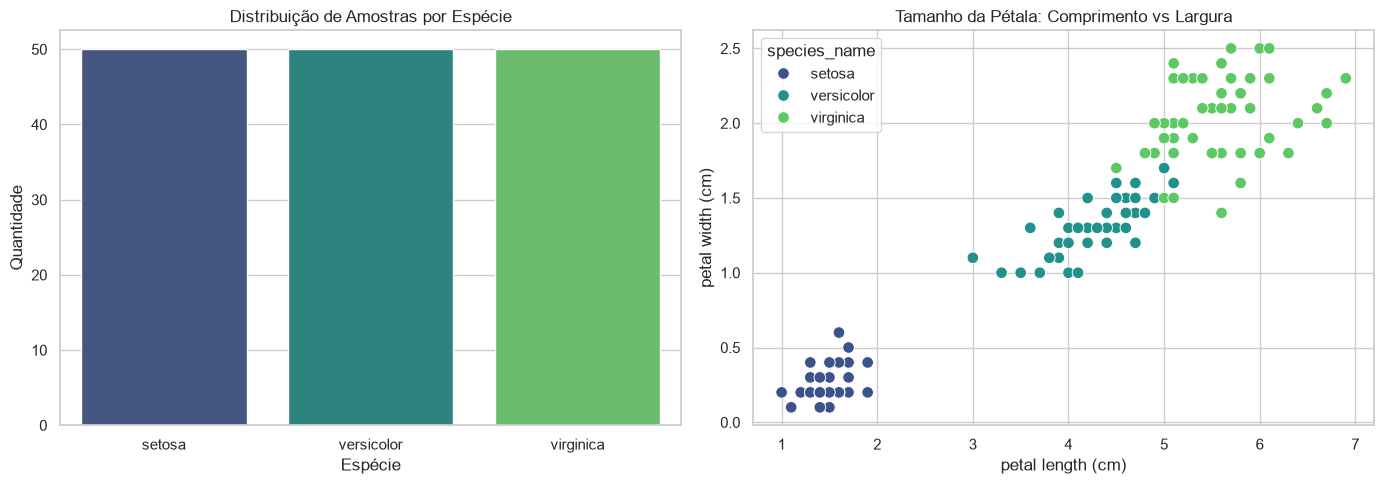

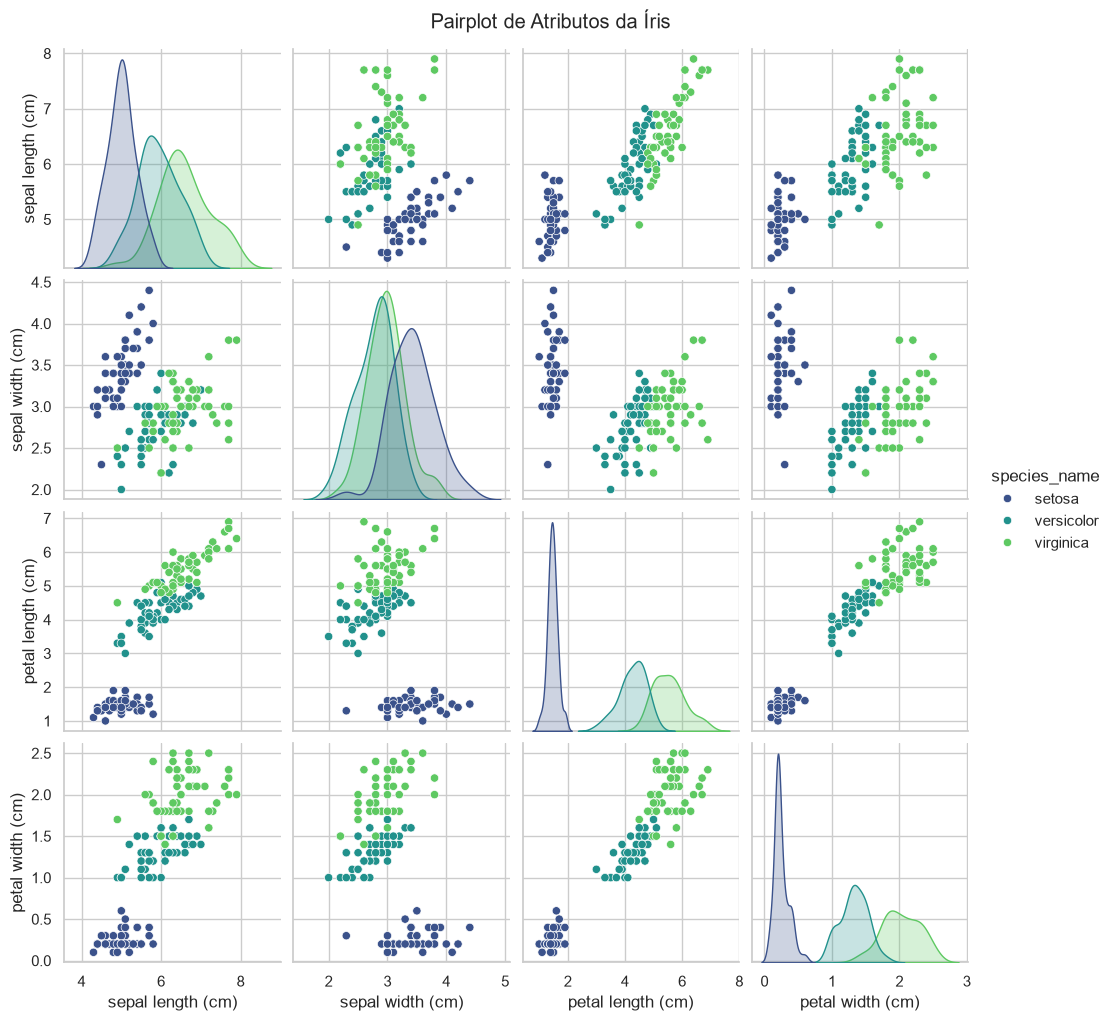

In [9]:
# Gráfico 1: Distribuição de amostras por classe
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='species_name', palette='viridis', ax=ax[0])
ax[0].set_title('Distribuição de Amostras por Espécie')
ax[0].set_xlabel('Espécie')
ax[0].set_ylabel('Quantidade')

# Gráfico 2: Comprimento vs Largura da Pétala
sns.scatterplot(
    data=df, 
    x='petal length (cm)', 
    y='petal width (cm)', 
    hue='species_name', 
    palette='viridis', 
    s=70, 
    ax=ax[1]
)
ax[1].set_title('Tamanho da Pétala: Comprimento vs Largura')

plt.tight_layout()
plt.show()

# Gráfico 3: Pairplot de atributos
sns.pairplot(df.drop(columns=['target']), hue='species_name', palette='viridis')
plt.suptitle('Pairplot de Atributos da Íris', y=1.02)
plt.show()

## 3. Preparação dos Dados e Divisão Treino/Teste

In [10]:
# Separação entre variáveis explicativas (X) e alvo (y)
X = df.drop(columns=['target', 'species_name'])
y = df['target']

# Divisão: 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Padronização de escalas (Média = 0, Desvio Padrão = 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Amostras de Treino: {X_train_scaled.shape[0]}")
print(f"Amostras de Teste:  {X_test_scaled.shape[0]}")

Amostras de Treino: 120
Amostras de Teste:  30


## 4. Treinamento do Modelo Baseline

In [11]:
model = LogisticRegression(random_state=42, max_iter=200)
model.fit(X_train_scaled, y_train)

print("✅ Modelo de Regressão Logística treinado com sucesso!")

✅ Modelo de Regressão Logística treinado com sucesso!


## 5. Avaliação do Desempenho

🎯 Acurácia no conjunto de teste: 93.33%

📊 Relatório Detalhado de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



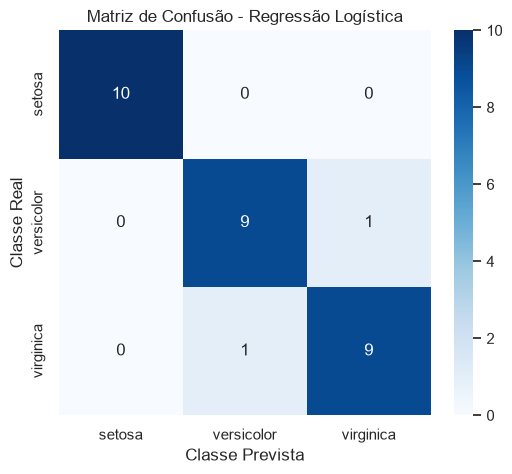

In [12]:
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"🎯 Acurácia no conjunto de teste: {acc * 100:.2f}%\n")

print("📊 Relatório Detalhado de Classificação:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=iris.target_names, 
    yticklabels=iris.target_names
)
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.show()

## 7. Comparação de Modelos e Validação Cruzada (K-Fold)

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# 1. Treinamento da Árvore de Decisão (DecisionTreeClassifier)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Avaliação rápida no conjunto de teste
y_pred_dt = dt_model.predict(X_test_scaled)
acc_dt = accuracy_score(y_test, y_pred_dt)

# 2. Validação Cruzada (5 Folds) sobre todo o dataset padronizado
X_scaled = scaler.fit_transform(X)

cv_scores_lr = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
cv_scores_dt = cross_val_score(dt_model, X_scaled, y, cv=5, scoring='accuracy')

# 3. Tabela Comparativa de Resultados
df_comparacao = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Árvore de Decisão'],
    'Acurácia (Teste Directo)': [acc, acc_dt],
    'Acurácia Média (5-Fold CV)': [cv_scores_lr.mean(), cv_scores_dt.mean()],
    'Desvio Padrão (CV)': [cv_scores_lr.std(), cv_scores_dt.std()]
})

print("📊 Comparação de Desempenho entre Modelos:")
display(df_comparacao)

📊 Comparação de Desempenho entre Modelos:


,Modelo,Acurácia (Teste Directo),Acurácia Média (5-Fold CV),Desvio Padrão (CV)
0,Regressão Logística,0.933333,0.960000,0.038873
1,Árvore de Decisão,0.933333,0.953333,0.033993


### 💡 Análise dos Resultados:
- **Regressão Logística:** Apresenta boa estabilidade devido à natureza linear dos dados do dataset Iris.
- **Validação Cruzada:** Reduz o viés da divisão treino/teste aleatória, permitindo avaliar o modelo em 5 combinações diferentes de dados.